In [2]:
!pip install imbalanced-learn

In [ ]:
#  Stroke Risk Prediction using Decision Tree and KNN
#  Dataset : Healthcare Stroke Dataset (5110 records)

In [ ]:
# Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics
from imblearn.over_sampling import SMOTE

In [ ]:
#  Load the Dataset

In [4]:
dataset = pd.read_csv('healthcare-dataset-stroke-data.csv')
dataset.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#  Explore the Dataset

In [5]:
# Shape of the dataset
print(dataset.shape)

# Basic statistics
dataset.describe()

# Check data types
print(dataset.dtypes)

# Check stroke class distribution - to see if dataset is balanced
stroke_counts = dataset['stroke'].value_counts()
print(stroke_counts)

# Show as percentage
print(dataset['stroke'].value_counts(normalize=True) * 100)

(5110, 12)
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
#  Check for Missing Values

In [6]:
# The bmi column stores missing values as string 'N/A' not actual NaN
print(dataset.isnull().sum())

# Show how many bmi values are missing
print('Missing bmi values:', (dataset['bmi'] == 'N/A').sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
Missing bmi values: 0


In [ ]:
#  Handle Missing Values in bmi

In [7]:
# Replace 'N/A' string with actual NaN first, then convert to float
dataset['bmi'] = dataset['bmi'].replace('N/A', np.nan)
dataset['bmi'] = dataset['bmi'].astype(float)

# Fill missing bmi with median - median is better than mean for skewed data
dataset['bmi'] = dataset['bmi'].fillna(dataset['bmi'].median())

# Confirm no more nulls
print(dataset.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
#  Remove Unnecessary Column and Rows

In [8]:
# Drop id column - it is just a row number, not a useful feature
dataset = dataset.drop(columns=['id'])

# Remove the one row where gender is 'Other' to avoid encoding issues
dataset = dataset[dataset['gender'] != 'Other']
dataset = dataset.reset_index(drop=True)

print(dataset.shape)

(5109, 11)


In [ ]:
#  Handle Outliers using IQR Method

In [9]:
# Cap outliers in numerical columns using IQR
# We cap rather than delete because extreme values may be real medical cases
for col in ['age', 'avg_glucose_level', 'bmi']:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    dataset[col] = dataset[col].clip(lower, upper)

print('Outlier handling done')

Outlier handling done


In [ ]:
#  Label Encoding for Categorical Columns

In [10]:
le = LabelEncoder()

dataset['gender']         = le.fit_transform(dataset['gender'])
dataset['ever_married']   = le.fit_transform(dataset['ever_married'])
dataset['work_type']      = le.fit_transform(dataset['work_type'])
dataset['Residence_type'] = le.fit_transform(dataset['Residence_type'])
dataset['smoking_status'] = le.fit_transform(dataset['smoking_status'])

dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,169.365,36.6,1,1
1,0,61.0,0,0,1,3,0,169.365,28.1,2,1
2,1,80.0,0,1,1,2,0,105.920,32.5,2,1
3,0,49.0,0,0,1,2,1,169.365,34.4,3,1
4,0,79.0,1,0,1,3,0,169.365,24.0,2,1


In [ ]:
#  Correlation Heatmap

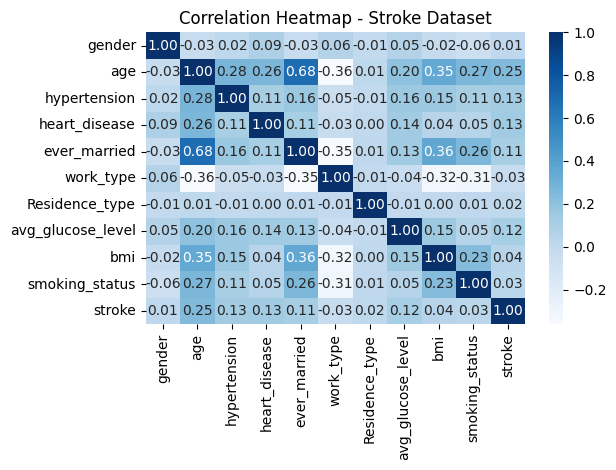

In [11]:
plt.figure(1)
sns.heatmap(dataset.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap - Stroke Dataset')
plt.tight_layout()
plt.show()

In [ ]:
#  Separate Features and Target

In [12]:
# Separate the features
X = dataset.drop(columns=['stroke'])

# Separate the target
Y = dataset['stroke']

print(X.shape)
print(Y.shape)

(5109, 10)
(5109,)


In [ ]:
#  Train Test Split

In [13]:
# Split data - 25% for testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0, stratify=Y)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(3831, 10)
(1278, 10)
(3831,)
(1278,)


In [ ]:
#  Handle Class Imbalance using SMOTE

stroke
0    3644
1    3644
Name: count, dtype: int64


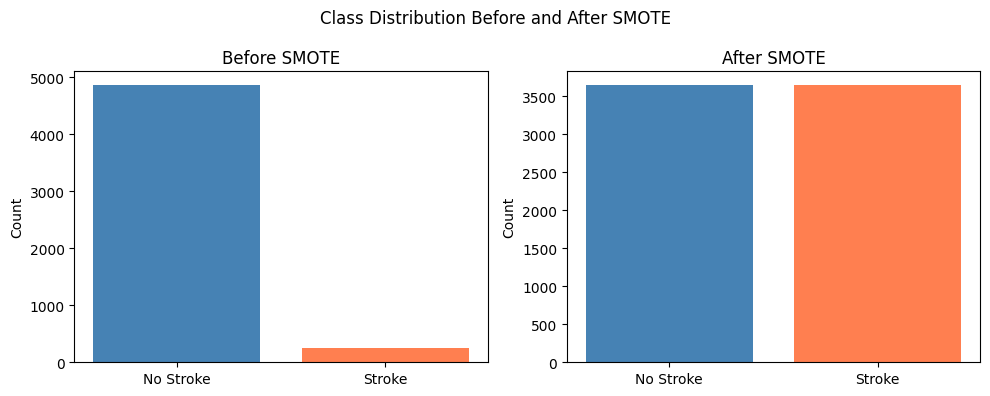

In [14]:
# Dataset has 95% no-stroke and 5% stroke - very imbalanced
# SMOTE creates synthetic minority samples to balance the training data
# Applied only on training data to avoid data leakage

sm = SMOTE(random_state=0)
X_train, Y_train = sm.fit_resample(X_train, Y_train)

print(pd.Series(Y_train).value_counts())

# Show class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

original_counts = Y.value_counts()
axes[0].bar(['No Stroke', 'Stroke'],
            [original_counts[0], original_counts[1]],
            color=['steelblue', 'coral'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

smote_counts = pd.Series(Y_train).value_counts()
axes[1].bar(['No Stroke', 'Stroke'],
            [smote_counts[0], smote_counts[1]],
            color=['steelblue', 'coral'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before and After SMOTE')
plt.tight_layout()
plt.show()

In [ ]:
#  Feature Scaling using StandardScaler

In [15]:
# KNN uses distance so all features must be on the same scale
# Fit on train data only, then transform both train and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [ ]:
#  Decision Tree Classifier

In [16]:
classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=0)

classifier.fit(X_train, Y_train)

y_pred_dt = classifier.predict(X_test)

# Summary of the predictions made by the classifier
print(classification_report(Y_test, y_pred_dt,
      target_names=['No Stroke', 'Stroke']))
print(confusion_matrix(Y_test, y_pred_dt))

# Accuracy score
print('accuracy is', accuracy_score(y_pred_dt, Y_test))

              precision    recall  f1-score   support

   No Stroke       0.98      0.77      0.86      1216
      Stroke       0.12      0.63      0.20        62

    accuracy                           0.76      1278
   macro avg       0.55      0.70      0.53      1278
weighted avg       0.93      0.76      0.83      1278

[[932 284]
 [ 23  39]]
accuracy is 0.7597809076682316


In [ ]:
#  Decision Tree - Confusion Matrix Details

[[932 284]
 [ 23  39]]
TP = 39
TN = 932
FP = 284
FN = 23
Specificity =  0.7664473684210527
Sensitivity =  0.6290322580645161
Precision: 0.12074303405572756
Recall: 0.6290322580645161
F-score: 0.2025974025974026


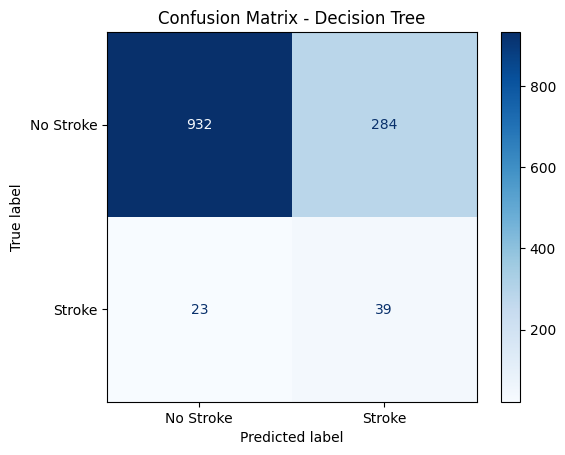

In [17]:
cm_dt = confusion_matrix(Y_test, y_pred_dt)
print(cm_dt)

TN = cm_dt[0][0]
FN = cm_dt[1][0]
FP = cm_dt[0][1]
TP = cm_dt[1][1]

print('TP =', TP)
print('TN =', TN)
print('FP =', FP)
print('FN =', FN)

print('Specificity = ', TN / (TN + FP))
print('Sensitivity = ', TP / (TP + FN))

print("Precision:", metrics.precision_score(Y_test, y_pred_dt))
print("Recall:",    metrics.recall_score(Y_test, y_pred_dt))
print("F-score:",   metrics.f1_score(Y_test, y_pred_dt))

# Print confusion matrix as visual heatmap
cm_dt_display = confusion_matrix(Y_test, y_pred_dt,
                                 labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt_display,
                              display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [ ]:
#  Feature Importance from Decision Tree

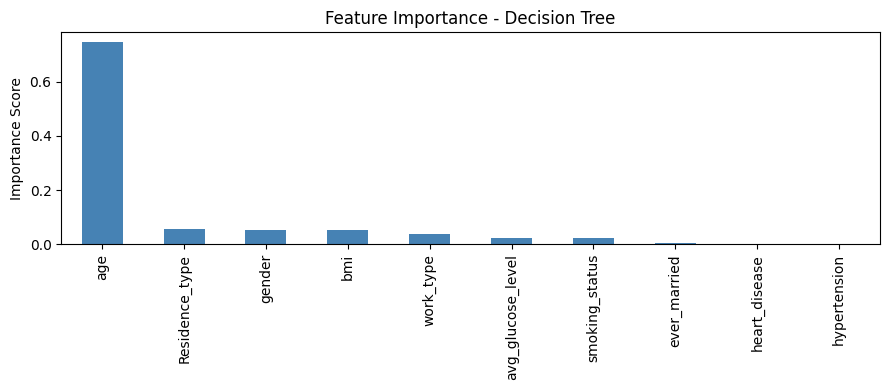

In [18]:
importances = pd.Series(
    classifier.feature_importances_,
    index=X.columns).sort_values(ascending=False)

importances.plot(kind='bar', figsize=(9, 4), color='steelblue')
plt.title('Feature Importance - Decision Tree')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Decision Tree Structure - Stroke Prediction

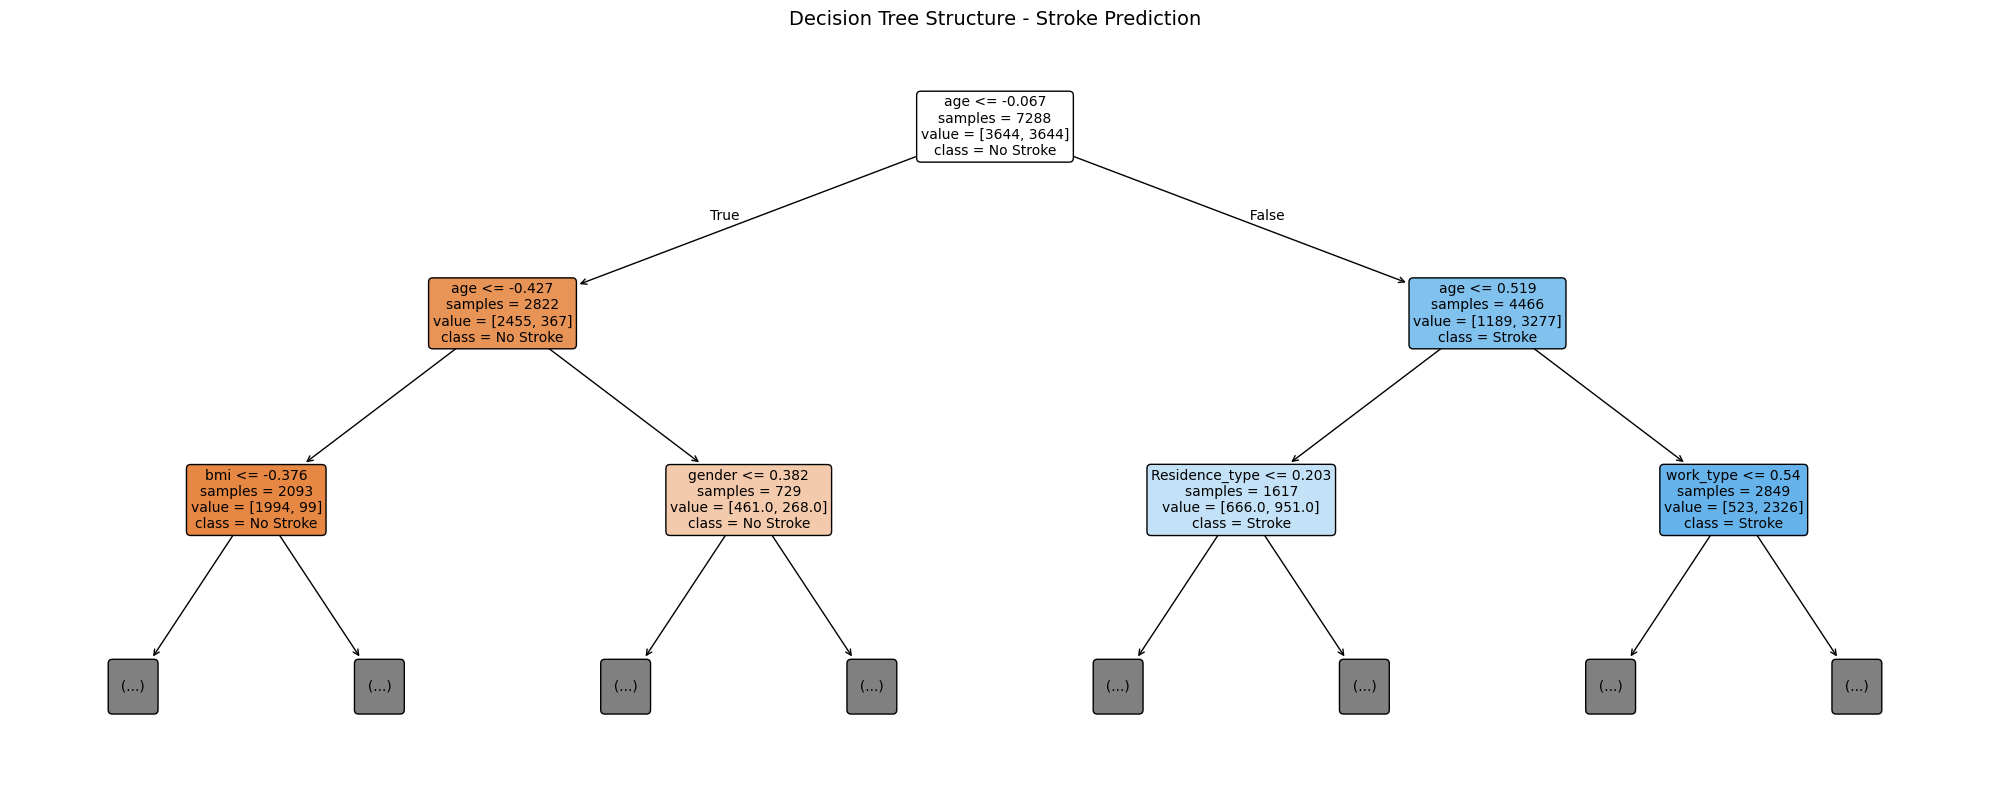

In [19]:
plt.figure(figsize=(20, 8))
plot_tree(classifier,
          feature_names=X.columns.tolist(),
          class_names=['No Stroke', 'Stroke'],
          filled=True,
          rounded=True,
          max_depth=2,
          fontsize=10,
          impurity=False)
plt.title('Decision Tree Structure - Stroke Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
#  KNN - Find Best K Value

Best k = 3


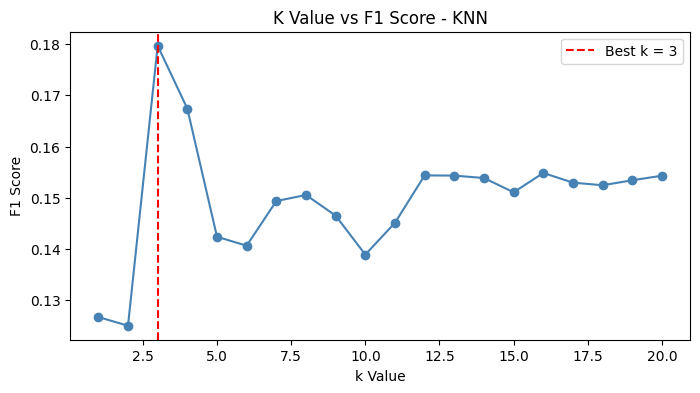

In [20]:
# Try k from 1 to 20 and find which k gives the best F1 score
# F1 score used because accuracy alone is misleading for imbalanced data
from sklearn.metrics import f1_score

k_values = range(1, 21)
f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, Y_train)
    pred_temp = knn_temp.predict(X_test)
    f1_scores.append(f1_score(Y_test, pred_temp))

best_k = list(k_values)[f1_scores.index(max(f1_scores))]
print('Best k =', best_k)

# Plot k vs F1 score
plt.figure(figsize=(8, 4))
plt.plot(k_values, f1_scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--',
            label='Best k = ' + str(best_k))
plt.xlabel('k Value')
plt.ylabel('F1 Score')
plt.title('K Value vs F1 Score - KNN')
plt.legend()
plt.show()

In [ ]:
#  KNN Classifier

In [21]:
# Create the KNN model
knn_classifier = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='minkowski',
    p=2)

# Fit the model for the data
knn_classifier.fit(X_train, Y_train)

# Make the prediction
y_pred_knn = knn_classifier.predict(X_test)

# Summary of the predictions made by the classifier
print(classification_report(Y_test, y_pred_knn,
      target_names=['No Stroke', 'Stroke']))
print(confusion_matrix(Y_test, y_pred_knn))

# Accuracy score
print('accuracy is', accuracy_score(y_pred_knn, Y_test))

              precision    recall  f1-score   support

   No Stroke       0.96      0.86      0.91      1216
      Stroke       0.12      0.37      0.18        62

    accuracy                           0.84      1278
   macro avg       0.54      0.62      0.54      1278
weighted avg       0.92      0.84      0.87      1278

[[1045  171]
 [  39   23]]
accuracy is 0.8356807511737089


In [ ]:
#  KNN - Confusion Matrix Details

[[1045  171]
 [  39   23]]
TP = 23
TN = 1045
FP = 171
FN = 39
Specificity =  0.859375
Sensitivity =  0.3709677419354839
Precision: 0.11855670103092783
Recall: 0.3709677419354839
F-score: 0.1796875


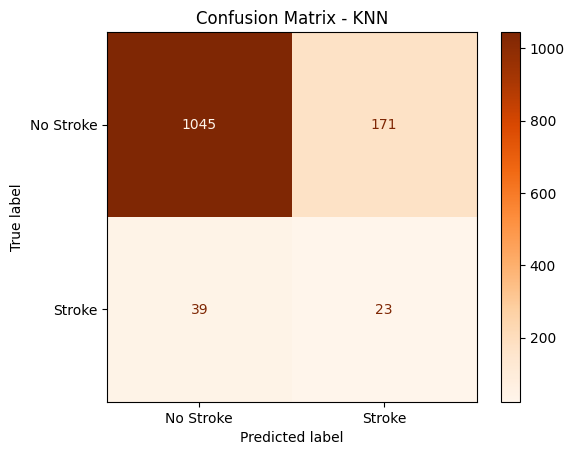

In [24]:
cm_knn = confusion_matrix(Y_test, y_pred_knn)
print(cm_knn)

TN = cm_knn[0][0]
FN = cm_knn[1][0]
FP = cm_knn[0][1]
TP = cm_knn[1][1]

print('TP =', TP)
print('TN =', TN)
print('FP =', FP)
print('FN =', FN)

print('Specificity = ', TN / (TN + FP))
print('Sensitivity = ', TP / (TP + FN))

print("Precision:", metrics.precision_score(Y_test, y_pred_knn))
print("Recall:",    metrics.recall_score(Y_test, y_pred_knn))
print("F-score:",   metrics.f1_score(Y_test, y_pred_knn))

# Print confusion matrix as visual heatmap
cm_knn_display = confusion_matrix(Y_test, y_pred_knn,
                                  labels=knn_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn_display,
                              display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix - KNN')
plt.show()

In [ ]:
#  ROC Curve Comparison

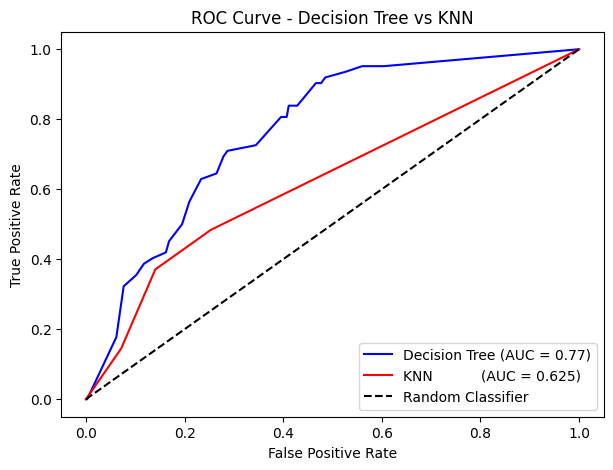

AUC - Decision Tree : 0.7697
AUC - KNN           : 0.6252


In [25]:
# Get probability scores needed for ROC curve
y_prob_dt  = classifier.predict_proba(X_test)[:, 1]
y_prob_knn = knn_classifier.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_dt,  tpr_dt,  _ = roc_curve(Y_test, y_prob_dt)
fpr_knn, tpr_knn, _ = roc_curve(Y_test, y_prob_knn)

# AUC scores
auc_dt  = roc_auc_score(Y_test, y_prob_dt)
auc_knn = roc_auc_score(Y_test, y_prob_knn)

# Plot both ROC curves together
plt.figure(figsize=(7, 5))
plt.plot(fpr_dt,  tpr_dt,
         label='Decision Tree (AUC = ' + str(round(auc_dt,  3)) + ')',
         color='blue')
plt.plot(fpr_knn, tpr_knn,
         label='KNN           (AUC = ' + str(round(auc_knn, 3)) + ')',
         color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree vs KNN')
plt.legend()
plt.show()

print('AUC - Decision Tree :', round(auc_dt,  4))
print('AUC - KNN           :', round(auc_knn, 4))

In [ ]:
#  Side by Side Confusion Matrix

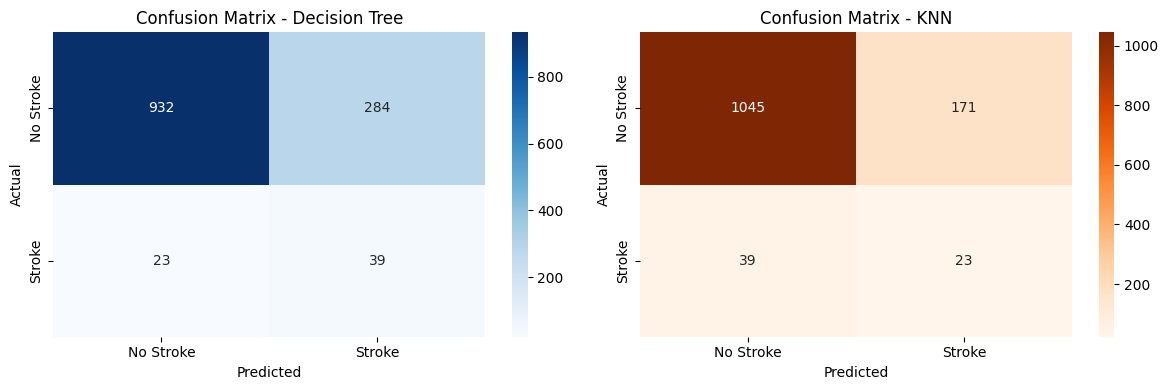

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(Y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(Y_test, y_pred_knn),
            annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[1].set_title('Confusion Matrix - KNN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
#  Final Metrics Comparison

========== Final Comparison ==========
Metric            Decision Tree        KNN
------------------------------------------
Accuracy                 0.7598     0.8357
Precision                0.1207     0.1186
Recall                   0.6290     0.3710
F1 Score                 0.2026     0.1797
AUC Score                0.7697     0.6252


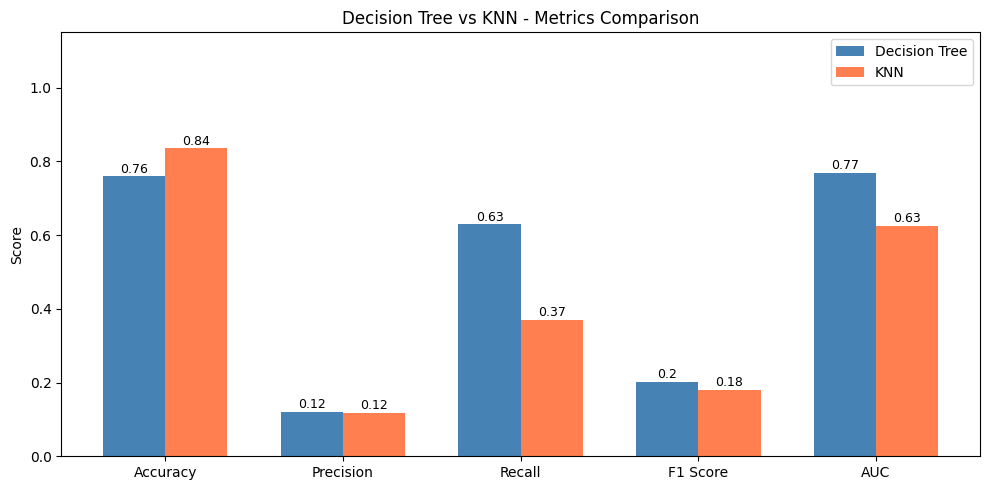

In [27]:
dt_accuracy  = accuracy_score(Y_test, y_pred_dt)
dt_precision = metrics.precision_score(Y_test, y_pred_dt)
dt_recall    = metrics.recall_score(Y_test, y_pred_dt)
dt_f1        = metrics.f1_score(Y_test, y_pred_dt)

knn_accuracy  = accuracy_score(Y_test, y_pred_knn)
knn_precision = metrics.precision_score(Y_test, y_pred_knn)
knn_recall    = metrics.recall_score(Y_test, y_pred_knn)
knn_f1        = metrics.f1_score(Y_test, y_pred_knn)

# Print comparison table
print("========== Final Comparison ==========")
print(f"{'Metric':<15} {'Decision Tree':>15} {'KNN':>10}")
print("-" * 42)
print(f"{'Accuracy':<15} {dt_accuracy:>15.4f} {knn_accuracy:>10.4f}")
print(f"{'Precision':<15} {dt_precision:>15.4f} {knn_precision:>10.4f}")
print(f"{'Recall':<15} {dt_recall:>15.4f} {knn_recall:>10.4f}")
print(f"{'F1 Score':<15} {dt_f1:>15.4f} {knn_f1:>10.4f}")
print(f"{'AUC Score':<15} {auc_dt:>15.4f} {auc_knn:>10.4f}")

# Bar chart comparing all metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
dt_scores    = [dt_accuracy, dt_precision, dt_recall, dt_f1, auc_dt]
knn_scores   = [knn_accuracy, knn_precision, knn_recall, knn_f1, auc_knn]

x     = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, dt_scores,  width, label='Decision Tree', color='steelblue')
plt.bar(x + width/2, knn_scores, width, label='KNN',           color='coral')
plt.xticks(x, metric_names)
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.title('Decision Tree vs KNN - Metrics Comparison')
plt.legend()

for i, (dt, knn) in enumerate(zip(dt_scores, knn_scores)):
    plt.text(i - width/2, dt  + 0.01, str(round(dt,  2)), ha='center', fontsize=9)
    plt.text(i + width/2, knn + 0.01, str(round(knn, 2)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
#  Exploratory Data Analysis (EDA) — Dataset Visualizations

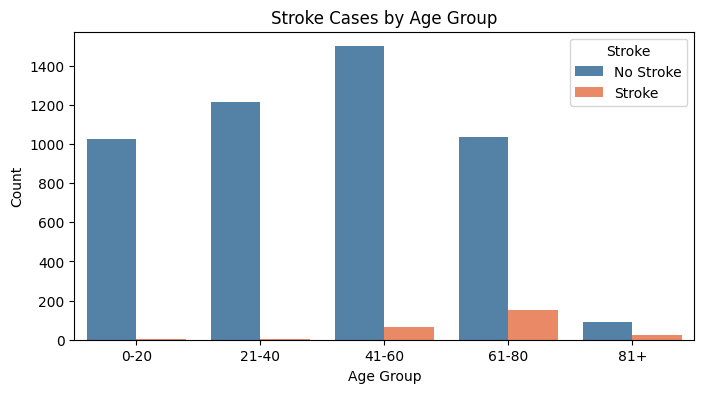

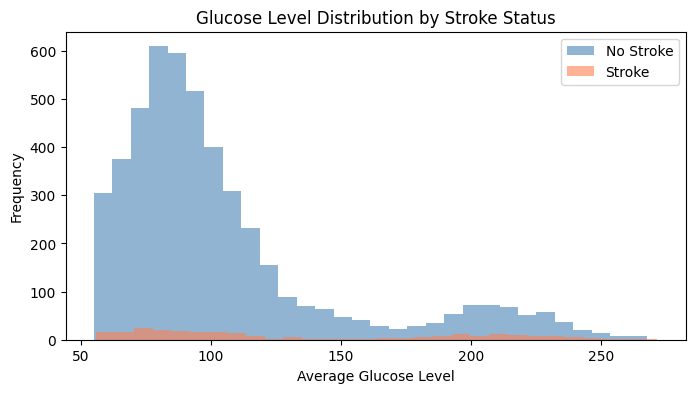

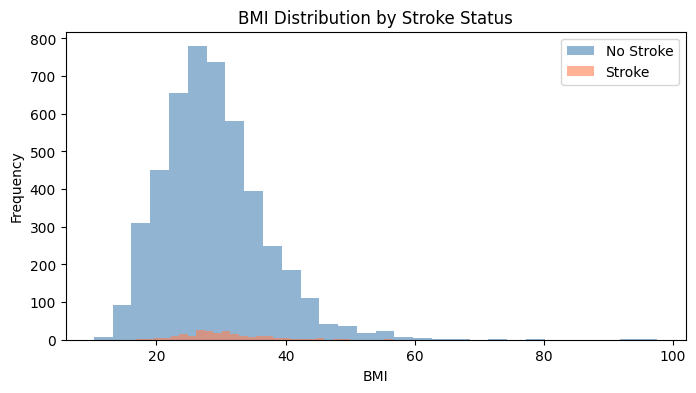

In [28]:
# Load original dataset again for clean visualizations before encoding
dataset_viz = pd.read_csv('healthcare-dataset-stroke-data.csv')
dataset_viz['bmi'] = dataset_viz['bmi'].replace('N/A', np.nan).astype(float)
dataset_viz = dataset_viz[dataset_viz['gender'] != 'Other']

# Stroke cases by age group
dataset_viz['age_group'] = pd.cut(dataset_viz['age'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81+'])

plt.figure(figsize=(8, 4))
sns.countplot(data=dataset_viz, x='age_group', hue='stroke',
              palette=['steelblue', 'coral'])
plt.title('Stroke Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

# Glucose level distribution by stroke status
plt.figure(figsize=(8, 4))
dataset_viz[dataset_viz['stroke'] == 0]['avg_glucose_level'].plot(
    kind='hist', bins=30, alpha=0.6, color='steelblue', label='No Stroke')
dataset_viz[dataset_viz['stroke'] == 1]['avg_glucose_level'].plot(
    kind='hist', bins=30, alpha=0.6, color='coral',     label='Stroke')
plt.title('Glucose Level Distribution by Stroke Status')
plt.xlabel('Average Glucose Level')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# BMI distribution by stroke status
plt.figure(figsize=(8, 4))
dataset_viz[dataset_viz['stroke'] == 0]['bmi'].plot(
    kind='hist', bins=30, alpha=0.6, color='steelblue', label='No Stroke')
dataset_viz[dataset_viz['stroke'] == 1]['bmi'].plot(
    kind='hist', bins=30, alpha=0.6, color='coral',     label='Stroke')
plt.title('BMI Distribution by Stroke Status')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.show()